**Uwagi znajdują się w kodzie i pod kodem. Generalnie nie było łatwo, Unsupervised Learning nie jest tak intuicyjne jak Supervised Learning - przynajmniej dla mnie.**

In [147]:
# ładujemy odpowiednie moduły i klasyfikatory
from pathlib import Path
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.linear_model import SGDClassifier

In [148]:
# funkcja do ładowania danych, miałem problem z odpowiednim odczytem danych bo nie wiedziałem że są w tych plikach białe znaki
# takie jak spacje - już dawno zapomniałem jaki to może być problem
def load_samsung_data():
      filename_train = "samsung_train.txt"
      filename_test = "samsung_test.txt"
      filename_labels = "samsung_train_labels.txt"
      Path("data/samsungData").mkdir(parents=True, exist_ok=True)
      return pd.read_csv(Path("data/samsungData") / filename_train, delim_whitespace=True, header=None), \
      pd.read_csv(Path("data/samsungData") / filename_test, delim_whitespace=True, header=None), \
      pd.read_csv(Path("data/samsungData") / filename_labels, delim_whitespace=True, header=None)
"""
trzy zmienne:
train_data - dane treningowe do trenowania modelu
test_data - dane testowe, które będą używane do oceny modelu i predycji
y - etykiety klas - dla algorytmów Supervided Learning
"""
train_data, test_data, y = load_samsung_data()

/tmp/ipython-input-148-307479344.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(Path("data/samsungData") / filename_train, delim_whitespace=True, header=None), \
/tmp/ipython-input-148-307479344.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pd.read_csv(Path("data/samsungData") / filename_test, delim_whitespace=True, header=None), \
/tmp/ipython-input-148-307479344.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pd.read_csv(Path("data/samsungData") / filename_labels, delim_whitespace=True, header=None)


In [149]:
# funkcja do rysowania klastrów
def plot_clusters(X, y=None):
    plt.figure(figsize=(15, 10))
    # drobna zmiana, warunek czy dane należą do klasy DataFrame, w tej chwili ten warunek jest zbędny , wcześniej był potrzebny gdy pisałem kod
    if isinstance(X, pd.DataFrame):
        X_np = X.values
    else:
        X_np = X

    plt.scatter(X_np[:, 0], X_np[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=15)
    plt.ylabel("$x_2$", fontsize=15, rotation=0)
    plt.grid()

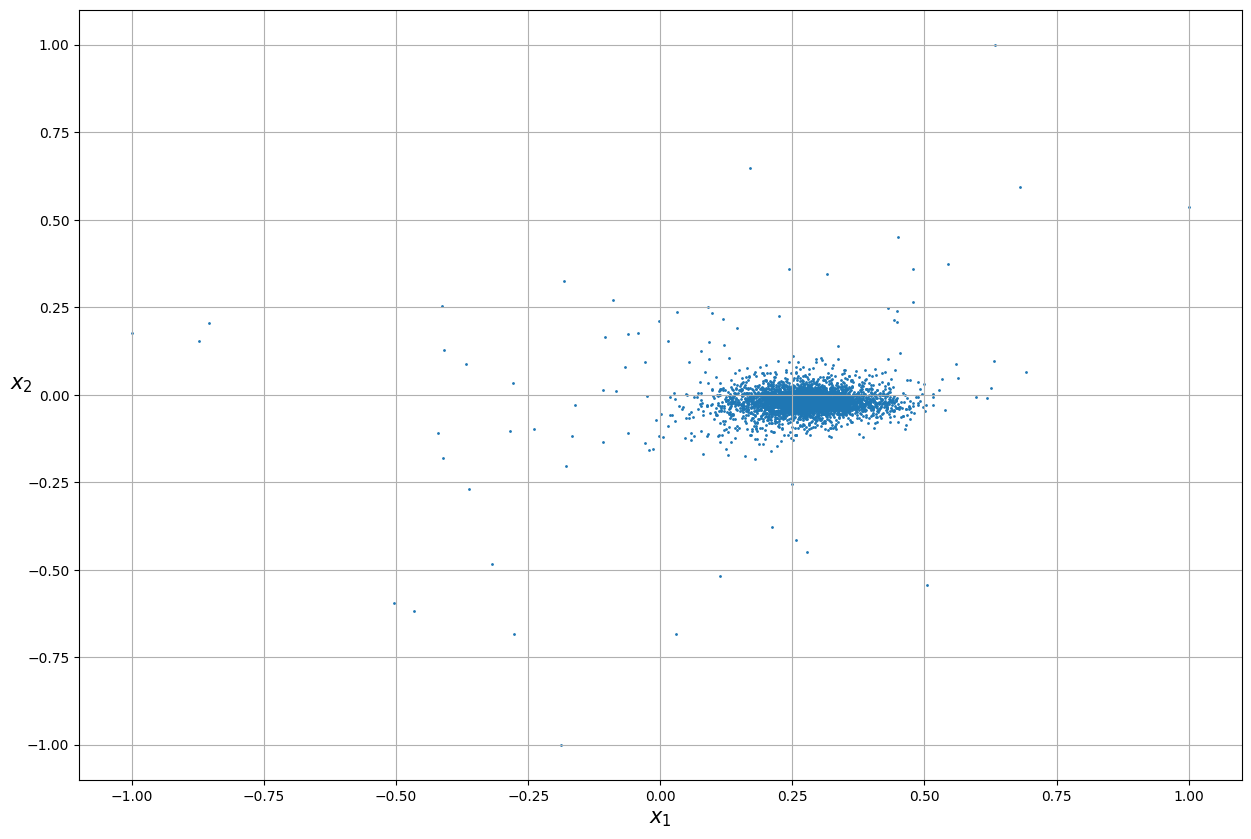

In [150]:
# rysujemy wykres klastrów, widzimy, że dane są raczej skocentrowane w jednym punkcie
plot_clusters(train_data)

In [151]:
# kilka metod służących do oceny danych, wcześniej gdy były w tych danych białe znaki, te metody pokazywały jakieś bzdury
train_data.head()

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [152]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, 0 to 560
dtypes: float64(561)
memory usage: 31.5 MB


In [153]:
train_data.describe()

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,0.125293,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.250994,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.023692,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,0.134000,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,0.289096,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000


In [154]:
# sprawdzam czy w danych są jakieś wartości NaN, nie ma więc nie trzeba zastosować metody dropna()
print(train_data.isna().sum())

0      0
1      0
2      0
3      0
4      0
      ..
556    0
557    0
558    0
559    0
560    0
Length: 561, dtype: int64


In [155]:
# wypisuje liste nazw kolumn, w tej chwili kod zbędny ale został
print("DataFrame columns:", train_data.columns.tolist())

DataFrame columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 

In [156]:
# skalowanie danych aby pozbyć się wartości odstających
scaler = StandardScaler()
X = scaler.fit_transform(train_data)
Y_test = scaler.transform(test_data)

In [157]:
# wykresy do wyznaczania granic decyzyjnych
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=3, linewidths=8,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(klasyfikator, X):
    # wyznaczanie granic decyzyjnych, podobnie jak w poprzednich notatnikach
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], 100),
                         np.linspace(mins[1], maxs[1], 100))
    Z = klasyfikator.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # rysowanie konturów granic
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")

    # rysowanie danych
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    # centra klastrów można wyciągnąc za pomocą zmiennej cluster_centers_
    plot_centroids(klasyfikator.cluster_centers_)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

In [158]:
# tutaj trenuje model tylko po to aby go później zwizualizować
clf = KMeans(n_clusters=6)
# pobieram z danych X wszystkie wiersze i tylko dwie kolumny tylko dlatgo abym mógł narysować wykres
# nie wiem dlaczego tak działa funkcja do rysowania wykresów, ale inaczej wykres nie działał - nie rysował się
clf.fit(X[:, :2])
clf_predict = clf.predict(Y_test[:, :2])
print("score dla danych testowych ", clf_predict)
"""
Tworzymy tablicę z klasyfikatorami, z wartościami n_clusters, jakie chcemy sprawdzić i szkolimy je na naszym zbiorze.
"""
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X)
                for k in range(1, 10)]


score dla danych testowych  [0 0 0 ... 2 0 1]


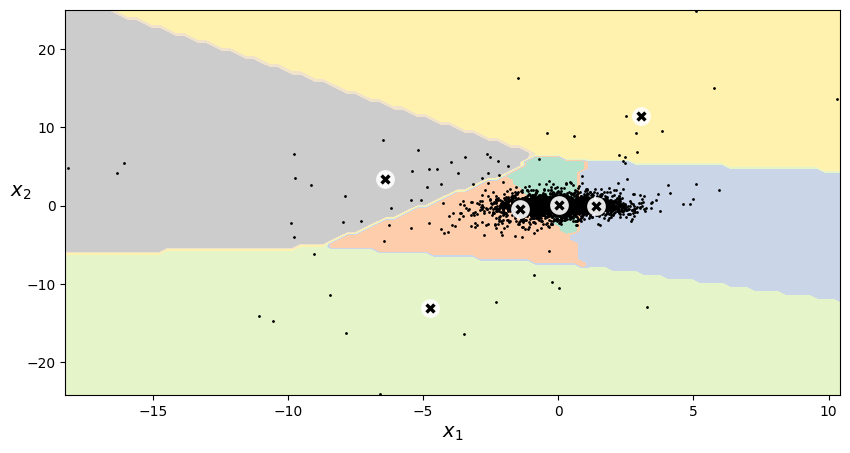

In [159]:
# wykres granic decyzyjnych z zaznaczonymi centroidami
plt.figure(figsize=(10, 5))
plot_decision_boundaries(clf, X)
plt.show()

In [160]:
"""
silhouette score oblicza jak punkty zostały dobrze przypisane do swoich klastrów
bliżej 1 - punkt jest dobrze przypisany do klastra
blisko 0 - punkt jest podobny do innego klastra, na granicy dwóch klastrów
bliżej -1 - punkt jest przypisany do złego klastra
"""
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

In [161]:
silhouette_scores

[np.float64(0.39650058094388707),
 np.float64(0.3274077920801446),
 np.float64(0.1613320617042328),
 np.float64(0.1306436986176042),
 np.float64(0.1086410631864108),
 np.float64(0.11142407811150756),
 np.float64(0.08959204796105176),
 np.float64(0.08376540113650399)]

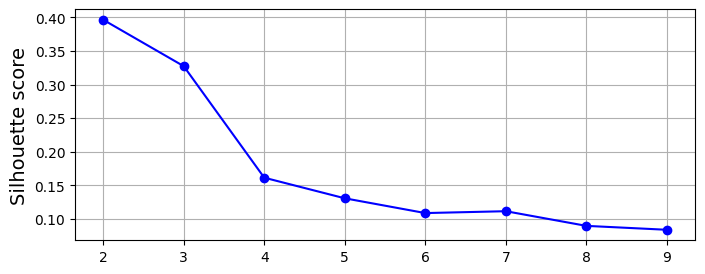

In [162]:
# wykres
plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.ylabel("Silhouette score", fontsize=14)
plt.grid()
plt.show()

In [163]:
# kolejny model do klasteryzacji
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.2)

In [164]:
# funkcja do rysowania modelu DBSCAN
def plot_dbscan(dbscan, X, size):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20, c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], marker=".")
    plt.title("eps={:.2f}, min_samples={}".format(dbscan.eps, dbscan.min_samples), fontsize=14)

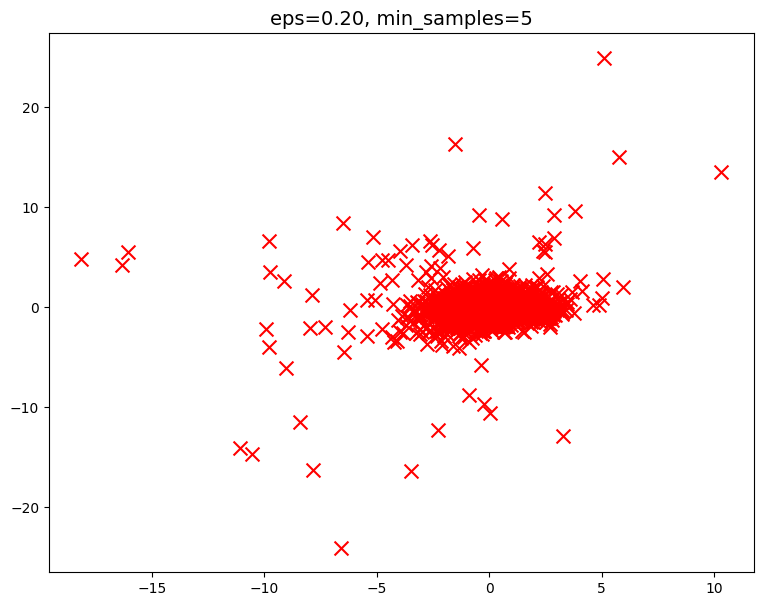

In [165]:
# rysujemy wykres, generalnie przy różnych epsilonach poziom anomalii jest podobny w tym przypadku
plt.figure(figsize=(20, 7))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.show()

In [137]:
# kolejny model do klasteryzacji
gm = GaussianMixture(n_components=3, n_init=5, random_state=42)
#gm.fit(X)
# tutaj ten sam problem co wcześniej, abym mógł narysować wykres muszę pobierać tylko 2 kolumny
gm.fit(X[:, :2])

GaussianMixture(n_components=3, n_init=5, random_state=42)

In [138]:
gm_predict = gm.predict(Y_test[:, :2])
print(gm_predict)

[2 0 0 ... 2 2 2]


In [139]:
# metoda zaporzyczona z przykładów sklearn oraz lekko zmodyfikowana zmodyfikowana
def plot_gaussian_mixture(clf, X, resolution=1000):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clf.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, linewidths=3, colors='b')

    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

    plt.xlabel("$x_1$", fontsize=14)
    plt.tick_params(labelleft=False)

/tmp/ipython-input-139-3521225473.py:10: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(xx, yy, Z,
/tmp/ipython-input-139-3521225473.py:13: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contour(xx, yy, Z,


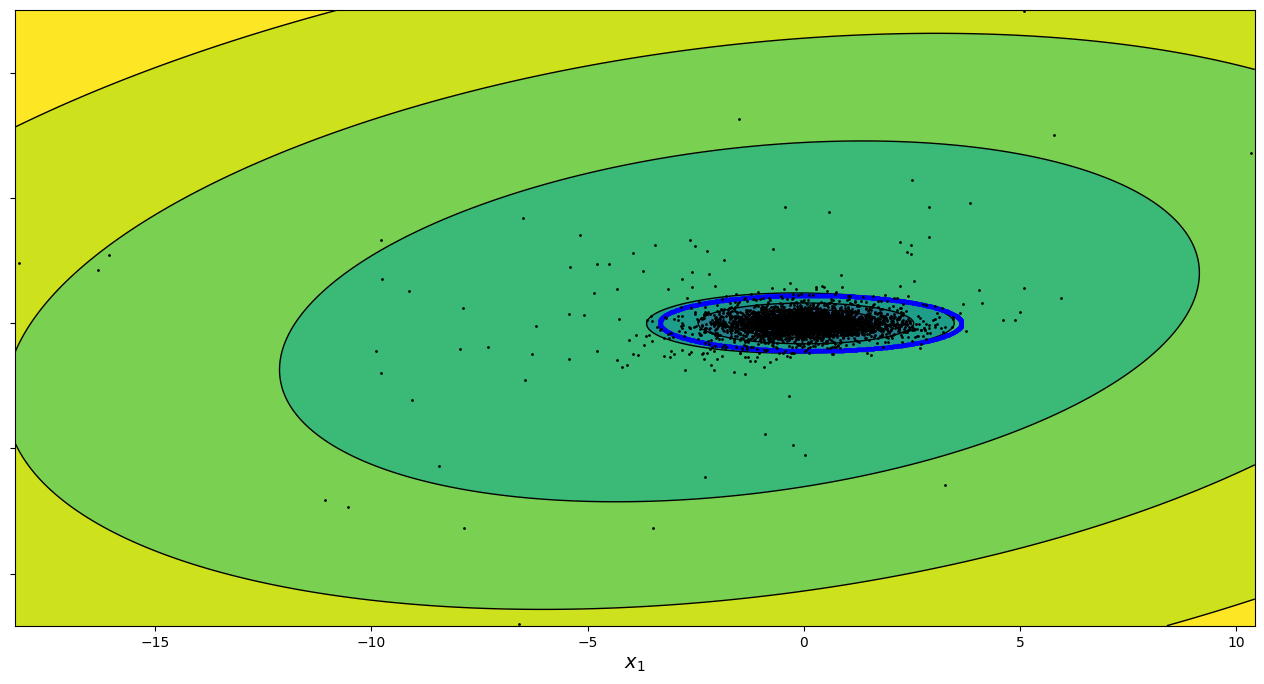

In [140]:
plt.figure(figsize=(16, 8))

plot_gaussian_mixture(gm, X)
plt.show()

In [141]:
y.head()

,0
0,5
1,5
2,5
3,5
4,5


In [142]:
# dzielimy nasze dane na treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [143]:
# pierwszy klasyfikator z rodziny Supervised Learning
forest_clf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
# trenujemy model
forest_clf.fit(X_train, y_train)
# wyniki tego klasyfikatora są bardzo dobre
print("score dla danych treningowych ", forest_clf.score(X_train, y_train))

print("score dla danych testowych ", forest_clf.score(X_test, y_test))

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


score dla danych treningowych  0.9493283455194694
score dla danych testowych  0.9360978925900748


In [144]:
# drugi klasyfikator z rodziny Supervised Learning
tree_clf = DecisionTreeClassifier(max_depth=10, random_state=2)

tree_clf.fit(X_train, y_train)
# wyniki tego modelu są nawet lepsze niż pierwszego modelu, zachodzi nawet obawa o overfitting
print("score dla danych treningowych ", tree_clf.score(X_train, y_train))

print("score dla danych testowych ", tree_clf.score(X_test, y_test))

score dla danych treningowych  0.9933684747491923
score dla danych testowych  0.9422161794697484


In [145]:
# stworzenie KFold obiektu z 5 foldami i tasowaniem danych
kf = KFold(n_splits=5, shuffle=True, random_state=1)

models = []
scores = []

# iteracja przez poszczególne foldy
for fold_nr, (train_idx, test_idx) in enumerate(kf.split(X)):
    # musiałem zmodyfikować ten kod bo dostawałem jakiś błąd odnośnie zakresu w tych listach
    # zakresy się różniły między danymi treningowymi a testowymi
    X_train = X[0:len(train_idx)]
    X_test =X[0:len(test_idx)]
    y_train = y[0:len(train_idx)]
    y_test = y[0:len(test_idx)]

    # skalowanie danych wewnątrz poszczeŋólnych iteracji
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # stworzenie klasyfikatora dla poszczególnej iteracji
    # wytrenowanie klasyfikatora na danych treningowych
    clf = SGDClassifier(random_state=1).fit(X_train, y_train)

    # dodawanie klasyfikatora do tablicy klasyfikatorów
    models.append(clf)
    # dodawanie wyniku dla danych testowych do tablicy
    scores.append(clf.score(X_test, y_test))

print("wyniki poszczególnych foldów: ", scores)
print("sredni wynik wszystkich foldów: ", np.array(scores).mean())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

wyniki poszczególnych foldów:  [0.9870836165873556, 0.9870836165873556, 0.9891156462585035, 0.9891156462585035, 0.9891156462585035]
sredni wynik wszystkich foldów:  0.9883028343900444


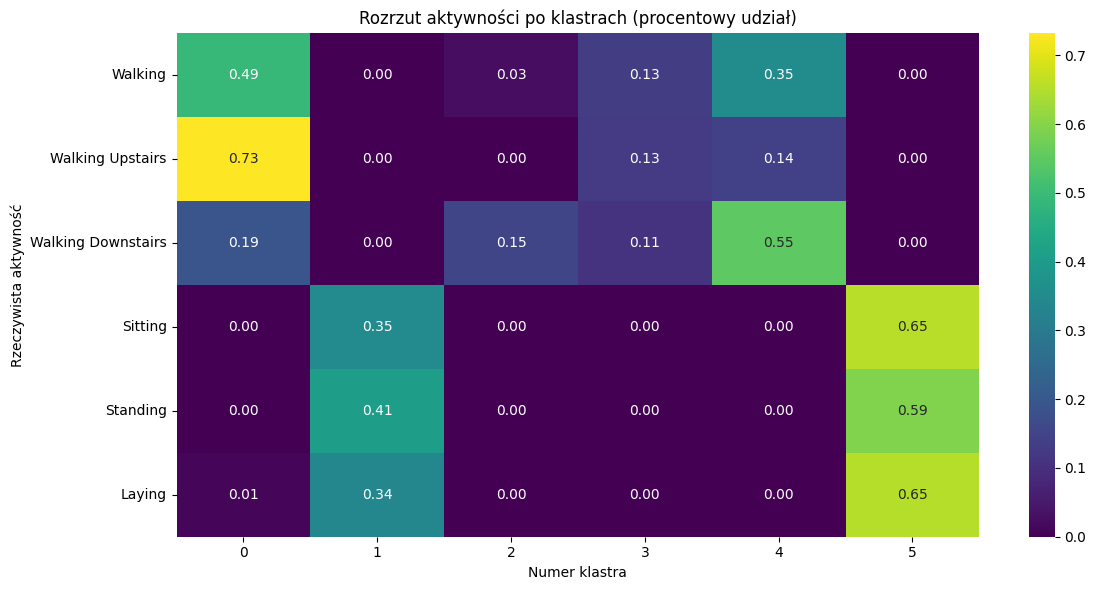

In [146]:
# ten fragment kodu odpowiada za odpowiedzenie na pytanie która aktywność występuję najczęściej w tym ćwiczeniu
# szczerze mówiąc nie do końca rozumiem te zadanie i po prostu skopiowałem kod z internetu
# a która aktywność występuję najczęsciej? to widać na rysunku w zależności od klastra w którym jesteśmy

kmeans = KMeans(n_clusters=6, random_state=42)
labels_pred = kmeans.fit_predict(X_train)

# Tabela krzyżowa: rzeczywiste etykiety vs przypisane klastry
activity_cluster_dist = pd.crosstab(y_train.iloc[:, 0], labels_pred, normalize='index')

# Mapowanie etykiet
activity_labels = {
    1: "Walking",
    2: "Walking Upstairs",
    3: "Walking Downstairs",
    4: "Sitting",
    5: "Standing",
    6: "Laying"
}
activity_cluster_dist.index = activity_cluster_dist.index.map(activity_labels)

# Sortowanie
activity_cluster_dist = activity_cluster_dist.loc[
    ["Walking", "Walking Upstairs", "Walking Downstairs", "Sitting", "Standing", "Laying"]
]

# Heatmapa
plt.figure(figsize=(12, 6))
sns.heatmap(activity_cluster_dist, annot=True, cmap="viridis", fmt=".2f")
plt.title("Rozrzut aktywności po klastrach (procentowy udział)")
plt.xlabel("Numer klastra")
plt.ylabel("Rzeczywista aktywność")
plt.tight_layout()
plt.show()

**Czym różni się KMeans, K-fold i K Nearest Neighbors**

**KMeans** - algorytm klasteryzacji, którego celem jest podział obserwacji na k klastrów(części) bez znajomości etykiet. Wybiera K centroidów i przypisuje punkty do najbliższego środka.

**K-fold** - ocenia skuteczność modelu. Dzielenie danych na K części(foldy) do treningu i testowania modelu. Proces jest powtarzany K razy.

**K Nearest Neighbors** - algorytm klasyfikacji lub regresji. Metoda uczenia nadzorowanego. Klasyfikowanie punktu na podstawie K najbliższych sąsiadów w danych treningowych.

Nie było łatwo więc liczę na wyrozumiałość przy ocenie mojej pracy.
